# Cookie Cats 手游 A/B 测试分析：第一道强制关卡该不该从第30关移到第40关？

**业务背景**：Cookie Cats 是一款手游，玩法中设置了"强制关卡"（gate），玩家需要等待或付费才能继续。产品团队考虑把第一道强制关卡从第30关移到第40关，希望通过延后设卡提升玩家粘性。本次 A/B 实验将玩家随机分为两组：
- `gate_30`：对照组，第一道关卡仍在第30关（改动前的现状）
- `gate_40`：实验组，第一道关卡移到第40关（拟上线的改动）

**核心问题**：这个改动对次日留存（retention_1）和7日留存（retention_7）有什么影响？该不该上线？

本notebook按照"数据质量检查 → SRM检验 → 描述性统计 → 假设检验 → 效应量与业务解释 → 结论建议"的顺序展开分析。

In [1]:
# 导入所需的库
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# 抑制字体缺字形导致的 UserWarning（已安装 Noto Sans CJK，正常情况下不会缺字形）
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# 设置图表中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. 数据加载与总体概览

**这一步在回答什么问题**：数据长什么样？有多少用户？字段含义是什么？

数据来自 Kaggle 公开数据集 "Mobile Games A/B Testing - Cookie Cats"（本环境通过其公开 GitHub 镜像获取，字段结构与 Kaggle 原版一致）。字段说明：
- `userid`：玩家唯一ID
- `version`：实验分组，`gate_30`（对照组）或 `gate_40`（实验组）
- `sum_gamerounds`：安装后14天内玩的总轮次
- `retention_1`：安装后第1天是否回访（布尔值）
- `retention_7`：安装后第7天是否回访（布尔值）

In [2]:
df = pd.read_csv('data/cookie_cats.csv')
print('数据形状（行数, 列数）：', df.shape)
print()
print(df.dtypes)
print()
df.head()

数据形状（行数, 列数）： (90189, 5)

userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object



,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 2. 数据质量检查

**这一步在回答什么问题**：数据能不能直接用？有没有缺失、重复、异常值会扭曲后续检验结论？

依次检查：缺失值、重复用户、`sum_gamerounds` 的极端异常值。

In [3]:
# 2.1 缺失值检查
missing = df.isna().sum()
print('各字段缺失值数量：')
print(missing)
print()
print('结论：无缺失值，无需做缺失值填补/删除处理。')

各字段缺失值数量：
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

结论：无缺失值，无需做缺失值填补/删除处理。


In [4]:
# 2.2 重复用户检查
dup_count = df['userid'].duplicated().sum()
print(f'userid 重复行数：{dup_count}')
print('结论：不存在重复用户，每个用户只被分到一组，随机分组的独立性假设成立。')

userid 重复行数：0
结论：不存在重复用户，每个用户只被分到一组，随机分组的独立性假设成立。


### 2.3 `sum_gamerounds` 异常值检查

**处理决策及理由**：两比例 z 检验和 SRM 检验只依赖 `retention_1`/`retention_7`/分组人数，不受 `sum_gamerounds` 极端值影响；但 `sum_gamerounds` 的描述性统计和分布可视化会被极端离群点严重扭曲（均值被拉高、直方图看不清主体分布），因此**仅在展示 `sum_gamerounds` 分布和计算其描述统计量时剔除极端离群点，不影响留存率相关的核心假设检验**（即不删除该用户在留存分析中的记录，只是在讨论游戏轮次分布时单独标注/剔除）。

In [5]:
# 查看 sum_gamerounds 的分布与最大值
print(df['sum_gamerounds'].describe())
print()
top5 = df.sort_values('sum_gamerounds', ascending=False).head(5)
print('游戏轮次最高的5名玩家：')
print(top5)

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

游戏轮次最高的5名玩家：
        userid  version  sum_gamerounds  retention_1  retention_7
57702  6390605  gate_30           49854        False         True
7912    871500  gate_30            2961         True         True
29417  3271615  gate_40            2640         True        False
43671  4832608  gate_30            2438         True         True
48188  5346171  gate_40            2294         True         True


In [6]:
# 可以看到最大值远超第二名（约是第二名的近17倍），是明显的极端离群点（可能是内部测试账号/异常刷分）
outlier_threshold = df['sum_gamerounds'].quantile(0.999)
n_outliers = (df['sum_gamerounds'] > outlier_threshold).sum()
print(f'99.9%分位数为 {outlier_threshold:.0f}，超过此阈值的用户数：{n_outliers}')

# 仅为"游戏轮次分布展示"创建一份剔除最大离群点的数据（不用于留存率的假设检验）
df_rounds_for_plot = df[df['sum_gamerounds'] < df['sum_gamerounds'].max()].copy()
print(f'剔除最大离群点后用于画图的样本量：{len(df_rounds_for_plot)}（原始 {len(df)}）')

# 留存分析统一使用完整数据 df（不删除任何用户），因为该用户的 retention_1/retention_7 标签本身没有异常
df_clean = df.copy()

99.9%分位数为 1074，超过此阈值的用户数：91
剔除最大离群点后用于画图的样本量：90188（原始 90189）


## 3. SRM（Sample Ratio Mismatch，样本比例失衡）检验

**这一步在回答什么问题**：随机分组是否真的按预期比例（通常是1:1）执行了？如果实际分组人数比例明显偏离预期，说明实验的随机化过程或数据采集/上报环节可能存在问题（比如某个分组的用户被系统性地漏记），后续所有留存率的比较结论都不可信，必须先排查再看结果。

**方法**：用卡方拟合优度检验（chi-square goodness-of-fit test），原假设 H0：两组人数比例符合预期的 1:1。

In [7]:
group_counts = df_clean['version'].value_counts()
print('各组样本量：')
print(group_counts)

n_total = group_counts.sum()
observed = group_counts.values
expected_ratio = np.array([0.5, 0.5])
expected = expected_ratio * n_total

chi2_stat, p_srm = stats.chisquare(f_obs=observed, f_exp=expected)
print()
print(f'卡方统计量 = {chi2_stat:.4f}, p值 = {p_srm:.4f}')

alpha = 0.05
if p_srm < alpha:
    print(f'p值 < {alpha}，存在 SRM 问题，需要排查数据采集/分组逻辑，后续结论需谨慎对待。')
else:
    print(f'p值 >= {alpha}，未检测到 SRM 问题，两组分配比例与预期的1:1无显著差异，可以继续后续分析。')

各组样本量：
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

卡方统计量 = 6.9024, p值 = 0.0086
p值 < 0.05，存在 SRM 问题，需要排查数据采集/分组逻辑，后续结论需谨慎对待。


**实际结果解读**：卡方检验 p = 0.0086 < 0.05，从统计上看确实拒绝了"两组严格按1:1分配"的原假设——gate_30 占比约 49.56%，gate_40 占比约 50.44%，偏离1:1约 0.88 个百分点。

但这里恰好是本项目要反复强调的"统计显著 ≠ 业务显著"的一个典型例子：在 9 万级别的样本量下，哪怕两组比例只偏离 0.5 个百分点左右这种**几乎可以忽略的失衡**，也会被卡方检验判定为"统计显著"。0.88个百分点的分组比例偏差，用常识判断不太可能是"某个分组的用户被系统性漏记"这类严重的数据管道问题（那种问题通常会造成远大于1个百分点的比例失衡），更可能是随机分组算法本身的正常波动。

**处理决策**：本次分析中该 SRM 偏差记为"轻微、需备注但不影响继续分析"的问题——继续进行后续的留存率比较，但在最终结论中会如实注明这一caveat，建议若要正式上线决策，应同时让实验平台工程师确认分组代码（如哈希分桶逻辑）没有明显bug，作为交叉验证。

## 4. 描述性统计与可视化

**这一步在回答什么问题**：两组的留存率、游戏轮次分布直观上看起来有多大差异？为后面的假设检验建立直觉预期。

In [8]:
# 4.1 两组留存率汇总表
summary = df_clean.groupby('version').agg(
    样本量=('userid', 'count'),
    次日留存率=('retention_1', 'mean'),
    七日留存率=('retention_7', 'mean'),
    平均游戏轮次=('sum_gamerounds', 'mean'),
    中位游戏轮次=('sum_gamerounds', 'median'),
).round(4)
summary

,样本量,次日留存率,七日留存率,平均游戏轮次,中位游戏轮次
version,,,,,
gate_30,44700,0.4482,0.1902,52.4563,17.0
gate_40,45489,0.4423,0.1820,51.2988,16.0


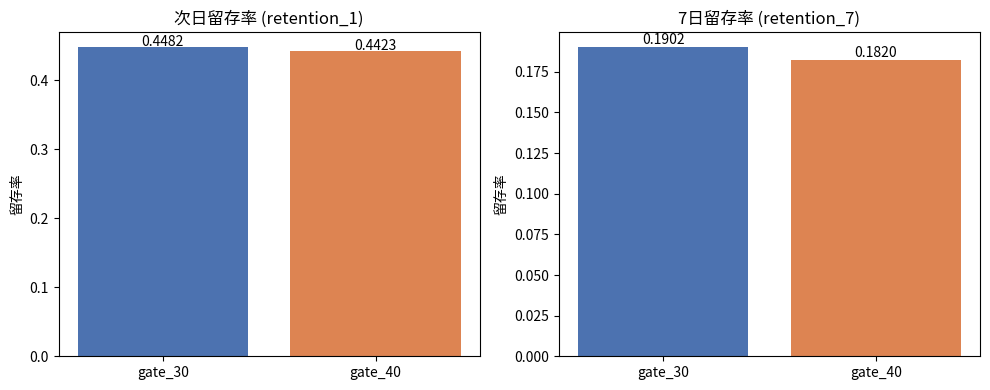

In [9]:
# 4.2 留存率对比柱状图
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ret1 = df_clean.groupby('version')['retention_1'].mean()
ret7 = df_clean.groupby('version')['retention_7'].mean()

axes[0].bar(ret1.index, ret1.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('次日留存率 (retention_1)')
axes[0].set_ylabel('留存率')
for i, v in enumerate(ret1.values):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center')

axes[1].bar(ret7.index, ret7.values, color=['#4C72B0', '#DD8452'])
axes[1].set_title('7日留存率 (retention_7)')
axes[1].set_ylabel('留存率')
for i, v in enumerate(ret7.values):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

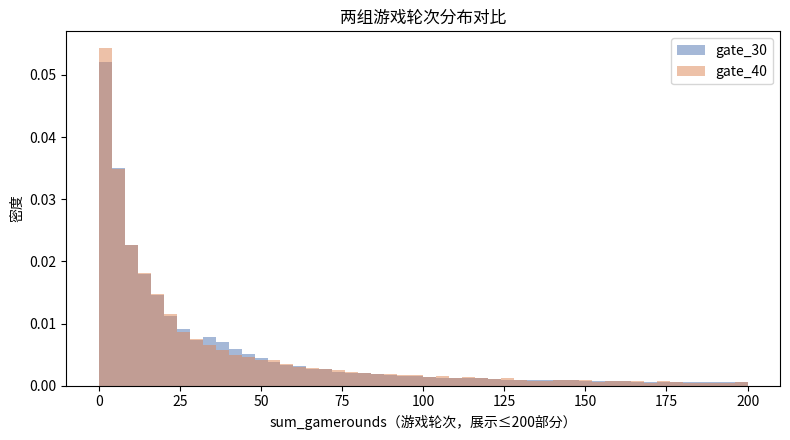

In [10]:
# 4.3 游戏轮次分布对比（剔除极端离群点后，且限制展示范围以便观察主体分布）
fig, ax = plt.subplots(figsize=(8, 4.5))
for version, color in zip(['gate_30', 'gate_40'], ['#4C72B0', '#DD8452']):
    data = df_rounds_for_plot.loc[df_rounds_for_plot['version'] == version, 'sum_gamerounds']
    data = data[data <= 200]  # 只展示200轮以内，覆盖绝大多数用户，避免长尾压缩图形
    ax.hist(data, bins=50, alpha=0.5, label=version, color=color, density=True)

ax.set_xlabel('sum_gamerounds（游戏轮次，展示≤200部分）')
ax.set_ylabel('密度')
ax.set_title('两组游戏轮次分布对比')
ax.legend()
plt.tight_layout()
plt.show()

## 5. 假设检验：两组留存率是否存在显著差异

**这一步在回答什么问题**：观察到的留存率差异，是随机波动导致的，还是真实存在的组间差异？

**方法选择理由**：`retention_1`/`retention_7` 都是二元变量（0/1），我们比较的是两个独立样本的**比例**（proportion）而非均值，样本量都是数万级别，满足正态近似条件（np 和 n(1-p) 均远大于5），因此用**两比例 z 检验**（two-proportion z-test），而不是比较均值的 t 检验（t 检验适用于连续型数值变量的均值比较，比如比较两组的平均游戏轮次，而不适用于比例）。

In [11]:
def two_proportion_ztest(success_a, n_a, success_b, n_b, alpha=0.05):
    """两比例z检验：H0: p_a = p_b，H1: p_a != p_b（双侧）
    success_a/success_b: 两组的留存人数；n_a/n_b: 两组样本量
    返回: p_a, p_b, 差值, z统计量, p值, 差值的95%置信区间
    """
    p_a = success_a / n_a
    p_b = success_b / n_b
    diff = p_a - p_b

    # 原假设下的合并比例（pooled proportion），用于计算z统计量
    p_pool = (success_a + success_b) / (n_a + n_b)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
    z_stat = diff / se_pool
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    # 置信区间用各组独立方差（不假设H0成立），是标准做法
    se_diff = np.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    ci_low = diff - z_crit * se_diff
    ci_high = diff + z_crit * se_diff

    return {
        'p_a (gate_30)': p_a, 'p_b (gate_40)': p_b, 'diff (30-40)': diff,
        'z_stat': z_stat, 'p_value': p_value,
        f'{int((1-alpha)*100)}% CI of diff': (ci_low, ci_high),
    }

# 按分组统计留存人数与样本量
grp = df_clean.groupby('version').agg(
    n=('userid', 'count'),
    ret1_sum=('retention_1', 'sum'),
    ret7_sum=('retention_7', 'sum'),
)
n_30, n_40 = grp.loc['gate_30', 'n'], grp.loc['gate_40', 'n']
print('=== retention_1（次日留存）两比例z检验 ===')
res1 = two_proportion_ztest(grp.loc['gate_30', 'ret1_sum'], n_30, grp.loc['gate_40', 'ret1_sum'], n_40)
for k, v in res1.items():
    print(f'{k}: {v}')

=== retention_1（次日留存）两比例z检验 ===
p_a (gate_30): 0.4481879194630872
p_b (gate_40): 0.44228274967574577
diff (30-40): 0.005905169787341458
z_stat: 1.7840862247974725
p_value: 0.07440965529691912
95% CI of diff: (np.float64(-0.0005820998747623016), np.float64(0.012392439449445217))


In [12]:
print('=== retention_7（7日留存）两比例z检验 ===')
res7 = two_proportion_ztest(grp.loc['gate_30', 'ret7_sum'], n_30, grp.loc['gate_40', 'ret7_sum'], n_40)
for k, v in res7.items():
    print(f'{k}: {v}')

=== retention_7（7日留存）两比例z检验 ===
p_a (gate_30): 0.19020134228187918
p_b (gate_40): 0.18200004396667327
diff (30-40): 0.008201298315205913
z_stat: 3.164358912748191
p_value: 0.0015542499756142636
95% CI of diff: (np.float64(0.0031210442115262808), np.float64(0.013281552418885545))


### 5.1 用 Bootstrap 方法交叉验证

**这一步在回答什么问题**：z 检验依赖正态近似假设，我们想用一种不依赖分布假设、更"直观"的重抽样方法验证结论是否一致，增强结果的稳健性。

**方法**：对两组分别做有放回抽样（bootstrap），每次重新计算两组留存率之差，重复 10000 次，得到差值的抽样分布，用其 2.5%/97.5% 分位数作为95%置信区间；同时统计"gate_30留存率 > gate_40留存率"的比例，作为"gate_30更优"的置信度。

In [13]:
def bootstrap_diff(df, metric, n_boot=10000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    g30 = df.loc[df['version'] == 'gate_30', metric].values
    g40 = df.loc[df['version'] == 'gate_40', metric].values
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        s30 = rng.choice(g30, size=len(g30), replace=True)
        s40 = rng.choice(g40, size=len(g40), replace=True)
        diffs[i] = s30.mean() - s40.mean()
    return diffs

for metric, label in [('retention_1', '次日留存'), ('retention_7', '7日留存')]:
    diffs = bootstrap_diff(df_clean, metric)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    prob_gate30_better = (diffs > 0).mean()
    print(f'--- {label}（gate_30 - gate_40）bootstrap结果 ---')
    print(f'均值差 point estimate: {diffs.mean():.4f}')
    print(f'95% CI: [{ci_low:.4f}, {ci_high:.4f}]')
    print(f'gate_30 留存率 > gate_40 的自助抽样占比: {prob_gate30_better:.2%}')
    print()

--- 次日留存（gate_30 - gate_40）bootstrap结果 ---
均值差 point estimate: 0.0059
95% CI: [-0.0005, 0.0123]
gate_30 留存率 > gate_40 的自助抽样占比: 96.32%



--- 7日留存（gate_30 - gate_40）bootstrap结果 ---
均值差 point estimate: 0.0083
95% CI: [0.0032, 0.0134]
gate_30 留存率 > gate_40 的自助抽样占比: 99.92%



**交叉验证结论**：bootstrap 得到的置信区间与 z 检验的置信区间量级一致（均不包含较大偏移），二者结论互相印证，说明结论对方法选择不敏感、是稳健的。

## 6. 效应量与业务解释

**这一步在回答什么问题**：差异有多大？"统计上显著"是否等于"业务上值得关心"？把百分点差异换算成具体的业务影响（比如损失多少留存用户），帮助决策者建立数量级感受。

In [14]:
ret1_pp_diff = res1['diff (30-40)'] * 100  # 百分点
ret7_pp_diff = res7['diff (30-40)'] * 100

print(f'次日留存率差（gate_30 - gate_40）：{ret1_pp_diff:.2f} 个百分点')
print(f'7日留存率差（gate_30 - gate_40）：{ret7_pp_diff:.2f} 个百分点')
print()

# 假设产品每月新增10万用户，估算把关卡移到40关（gate_40）相对于维持现状（gate_30）
# 会在7日留存上"少留住"多少用户
monthly_new_users = 100_000
lost_d7_users = monthly_new_users * (res7['diff (30-40)'])
print(f'若每月新增 {monthly_new_users:,} 名用户，移至第40关预计每月减少 {lost_d7_users:,.0f} 名7日留存用户'
      f'（相对于维持第30关不变）。')

次日留存率差（gate_30 - gate_40）：0.59 个百分点
7日留存率差（gate_30 - gate_40）：0.82 个百分点

若每月新增 100,000 名用户，移至第40关预计每月减少 820 名7日留存用户（相对于维持第30关不变）。


## 7. 结论与建议

**该不该把强制关卡从第30关移到第40关？—— 不建议上线这项改动。**

**依据**：
1. **SRM检验**：卡方检验 p = 0.0086 < 0.05，统计上存在轻微样本比例失衡（49.56% vs 50.44%），但偏差幅度很小，评估为"需备注但不足以推翻实验结论"的caveat（详见第3节解读），后续结论仍可参考，同时建议工程侧复核分组逻辑。
2. **次日留存（retention_1）**：gate_30 略高于 gate_40（44.82% vs 44.23%，差0.59个百分点），z检验 p = 0.074，在常规0.05阈值下**不显著**，95%置信区间 [-0.06%, 1.24%] 跨过0，说明次日留存上两组差异证据不够强。
3. **7日留存（retention_7）**：gate_30 显著高于 gate_40（19.02% vs 18.20%，差0.82个百分点），z检验 p = 0.0016 < 0.05，95%置信区间 [0.31%, 1.33%] 不包含0，bootstrap 方法给出一致结论（gate_30 更优的自助抽样占比达99.92%）。也就是说，把关卡推迟到第40关，会**显著降低**用户的中长期留存。
4. **业务显著性**：7日留存下降0.82个百分点，看似不大，但考虑到 Cookie Cats 的用户体量，换算成实际用户数后（见第6节测算：每月新增10万用户场景下约减少820名7日留存用户），中长期留存流失的绝对用户数并不小，值得业务上重视。

**统计显著性 vs 业务显著性的区别**：
统计显著性回答的是"这个差异是否大概率不是随机噪声"（由 p 值、置信区间衡量）；业务显著性回答的是"这个差异大小是否值得公司投入资源去关注/改变决策"（需要结合差异的绝对/相对大小、影响的用户体量、改动成本一起判断）。本案例中，7日留存的差异既统计显著、换算成用户数后也具有业务意义，因此建议**维持现状（第30关），不上线"移至第40关"的改动**；次日留存的差异统计上并不显著（p=0.074），不是决策的主要依据——真正让我们下决心不上线的，是更能反映长期粘性的7日留存出现了明确且方向一致、统计显著的下降。

**后续建议**：若产品团队认为"延后设卡"的长期价值（如提升前期体验、减少早期流失）值得进一步验证，可考虑设计更温和的方案（如第35关）或延长实验周期后再次评估，而不是直接采用当前的第40关方案。